In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Water infrastructure: change points without causal overreach

**Beginner route:** read the [case lesson](../lessons/nile.md) and [dataset card](../cards/nile.md). Predict each result before executing.

Source: [Cobb (1978), The Problem of the Nile; statsmodels distribution.](https://www.statsmodels.org/stable/datasets/generated/nile.html). Snapshot obtained by offline export from statsmodels 0.14.6. Numerical results below are our computations, not source claims.

This fixed test partition is a teaching demonstration, not an untouched future benchmark.

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, Ridge, LinearRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, log_loss, mean_absolute_error, mean_squared_error, roc_auc_score, confusion_matrix
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/shape_lab").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from shape_lab.industries import *
from shape_lab.persistence import rips_filtration, persistent_homology, diagram
CASE = "nile"
OUT = ROOT / "reports/v6/industries" / CASE
OUT.mkdir(parents=True, exist_ok=True)
SEED = 20260920

def write_json(name, value):
    def convert(x):
        if isinstance(x, np.ndarray): return x.tolist()
        if isinstance(x, np.generic): return x.item()
        raise TypeError(type(x).__name__)
    (OUT / name).write_text(json.dumps(value, indent=2, default=convert, allow_nan=False))

def plot_done(name):
    plt.tight_layout()
    plt.savefig(OUT / (name + ".png"), dpi=125)
    plt.show()

def regression_metrics(y, pred):
    return {"mae":float(mean_absolute_error(y,pred)),"rmse":float(mean_squared_error(y,pred)**.5)}

def class_metrics(y, pred):
    return {"accuracy":float(accuracy_score(y,pred)),"balanced_accuracy":float(balanced_accuracy_score(y,pred))}

def stratified_split(y):
    index=np.arange(len(y))
    train, other=train_test_split(index,test_size=.4,random_state=SEED,stratify=y)
    val,test=train_test_split(other,test_size=.5,random_state=SEED,stratify=y[other])
    return {"train":np.sort(train),"validation":np.sort(val),"test":np.sort(test)}

def save_split(split, ids):
    frames=[pd.DataFrame({"example_index":v,"source_id":np.asarray(ids)[v],"partition":k}) for k,v in split.items()]
    pd.concat(frames,ignore_index=True).to_csv(OUT / "split.csv",index=False)

def topology_report(points, name):
    bars=persistent_homology(rips_filtration(points,max_homology=1),max_dim=1)
    finite=[{"dimension":b.dim,"birth":b.birth,"death":b.death} for b in bars if np.isfinite(b.death)]
    write_json(name+".json",{"points":len(points),"coefficient_field":2,"edge_convention":"distance <= epsilon","finite_bars":finite,"essential_h0":1,"role":"exploratory descriptor, not significance"})
    plt.figure(figsize=(7,4))
    for dim in (0,1):
        a=diagram(bars,dim,finite_only=True)
        if len(a): plt.scatter(a[:,0],a[:,1],label="H"+str(dim),s=22)
    plt.xlabel("Birth (declared metric units)");plt.ylabel("Death (same units)");plt.title(name.replace('_',' '));plt.legend()
    plot_done(name)
    return finite

df, meta = load_dataset(CASE)
print(meta["title"])
print("Shape:",df.shape,"; snapshot SHA-256:",meta["data_sha256"])
print("Observation unit:",meta["observation_unit"])
display(df.head())
write_json("protocol.json",{"dataset":CASE,"seed":SEED,"data_sha256":meta["data_sha256"],"code_sha256":hashlib.sha256((ROOT/"src/shape_lab/industries.py").read_bytes()).hexdigest(),"data_kind":"observed","evaluation":"fixed teaching experiment; displayed test outcomes are now exposed","external_validation":False})


Retrospective change and forward evaluation
Shape: (100, 3) ; snapshot SHA-256: fa4813b7d95f16c78ca32a909e2de1979ed99959352e29850bcaab1dd8eab982
Observation unit: One annual river-volume observation, not an instantaneous discharge-rate sample.


,row_id,year,volume
0,0,1871,1120
1,1,1872,1160
2,2,1873,963
3,3,1874,1210
4,4,1875,1160


## 1. Define volume and chronology

The measurements are annual river volumes, in units of 100 million cubic metres. A volume is not a flow rate in cubic metres per second. There are one hundred years, not one hundred independent river systems. First partition years, then construct windows inside each partition.

In [3]:
values=df.volume.to_numpy(float);years=df.year.to_numpy();raw=ordered_split(years)
batch=past_windows(values,years,length=5,expected_step=1);split=assign_windows(batch,raw);save_split(split,batch.target)
print({k:(int(years[v[0]]),int(years[v[-1]])) for k,v in raw.items()})
print("Forecast examples:",{k:len(v) for k,v in split.items()})

{'train': (1871, 1930), 'validation': (1931, 1950), 'test': (1951, 1970)}
Forecast examples: {'train': 55, 'validation': 15, 'test': 15}


## 2. Find a descriptive change using training years only

We fit two constant means and choose the split with smallest within-segment squared error. The selected split is retrospective within the training period. A low error does not explain the cause, prove a change is significant, or justify moving a dam. Many candidate splits were inspected; ordinary one-test reasoning would ignore that search.

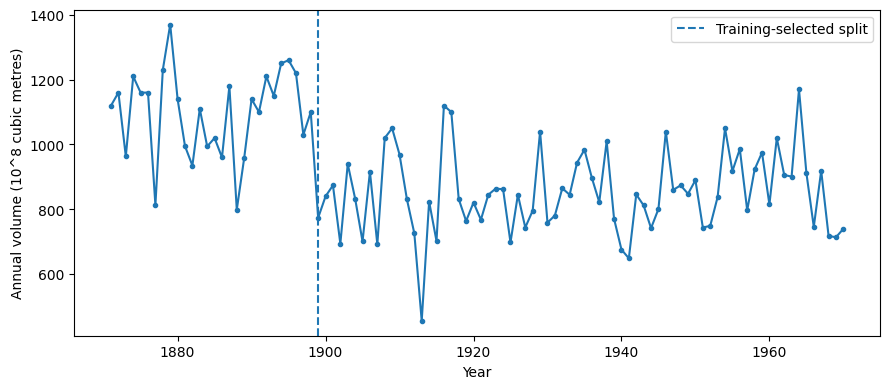

First year of fitted second regime: 1899


In [4]:
train=raw["train"];k,sse=best_mean_change(values[train],min_segment=10)
change_year=int(years[train[k]])
write_json("change_point.json",{"first_year_second_segment":change_year,"train_rows":train,"within_segment_sse":sse,"minimum_segment":10,"causal_claim":False})
plt.figure(figsize=(9,4));plt.plot(years,values,".-");plt.axvline(change_year,linestyle="--",label="Training-selected split")
plt.xlabel("Year");plt.ylabel("Annual volume (10^8 cubic metres)");plt.legend();plot_done("change_point")
print("First year of fitted second regime:",change_year)

## 3. Keep a forward prediction question separate

The change-point fit is not automatically a forecasting model. Here we independently compare last value, a fixed training mean, and a ridge model of five past annual readings. No causality or physical conservation law is enforced by any of them.

{'validation': {'ridge': {'mae': 96.16918539927487, 'rmse': 119.14036619504111}, 'last_value': {'mae': 104.8, 'rmse': 130.61801815471964}, 'training_mean': {'mae': 128.45333333333332, 'rmse': 147.4664808531302}, 'n': 15}, 'test': {'ridge': {'mae': 106.8941232115674, 'rmse': 126.64798795296238}, 'last_value': {'mae': 134.4, 'rmse': 158.55051771175857}, 'training_mean': {'mae': 110.38545454545455, 'rmse': 137.80349406022552}, 'n': 15}}


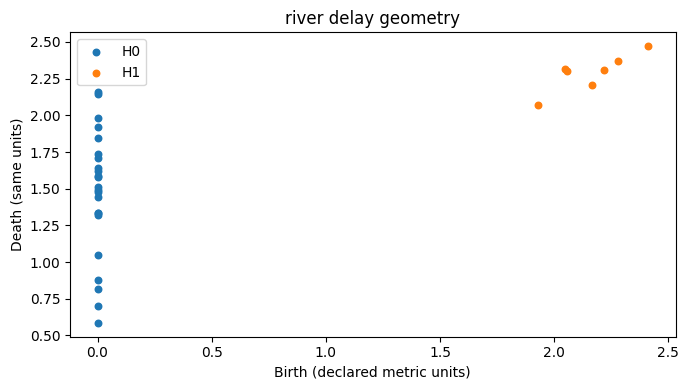

In [5]:
scale=TrainScaler.fit(batch.x[split["train"]]);z=scale.transform(batch.x)
model=Ridge(alpha=1).fit(z[split["train"]],batch.y[split["train"]]);mu=batch.y[split["train"]].mean();results={}
for key in ("validation","test"):
    ix=split[key];pred=model.predict(z[ix]);last=batch.x[ix,-1]
    results[key]={"ridge":regression_metrics(batch.y[ix],pred),"last_value":regression_metrics(batch.y[ix],last),"training_mean":regression_metrics(batch.y[ix],np.full(len(ix),mu)),"n":len(ix)}
    pd.DataFrame({"target_row":batch.target[ix],"year":years[batch.target[ix]],"observed":batch.y[ix],"ridge":pred,"last_value":last}).to_csv(OUT/(key+"_predictions.csv"),index=False)
write_json("results.json",results);print(results)
ix=np.random.default_rng(SEED).choice(split["train"],size=24,replace=False)
_ = topology_report(z[ix],"river_delay_geometry")

## 4. Identify what would be required for physics

A hydrological conservation model needs more than this scalar annual series: specify inflows, outflows, storage, rainfall, spatial boundaries and uncertainty. The manufactured PDE examples in the core course have these assumptions by construction; this observational series does not magically inherit them.

Transfer exercise: write one descriptive claim supported by the plot and one causal claim that it cannot support.

## Save your evidence

Create `my_work/industries/nile.md` with your prediction, actual result, explanation, one failed assumption and one claim the evidence does not justify. Use the separate learner notebook only after you understand the worked code. No notebook execution automatically marks your learning complete.